### Load the data and explore them, showing size, structure and histograms of numeric data; show the histogram of the frequencies of the class labels, contained in the “language” column

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'exam2022_01_13(1).csv'
random_state = 42

# Directives
%matplotlib inline
np.random.seed(random_state)
df=pd.read_csv(file_name)
df.head()

,language,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,ES,7.071476,-6.512900,7.650800,11.150783,-7.657312,12.484021,-11.709772,3.426596,1.462715,-2.812753,0.866538,-5.244274
1,ES,10.982967,-5.157445,3.952060,11.529381,-7.638047,12.136098,-12.036247,3.491943,0.595441,-4.508811,2.332147,-6.221857
2,ES,7.827108,-5.477472,7.816257,9.187592,-7.172511,11.715299,-13.847214,4.574075,-1.687559,-7.204041,-0.011847,-6.463144
3,ES,6.744083,-5.688920,6.546789,9.000183,-6.924963,11.710766,-12.374388,6.169879,-0.544747,-6.019237,1.358559,-6.356441
4,ES,5.836843,-5.326557,7.472265,8.847440,-6.773244,12.677218,-12.315061,4.416344,0.193500,-3.644812,2.151239,-6.816310


In [2]:
print(f"rows: {df.shape[0]}, cols: {df.shape[1]}")

rows: 329, cols: 13


<Axes: xlabel='language', ylabel='Count'>

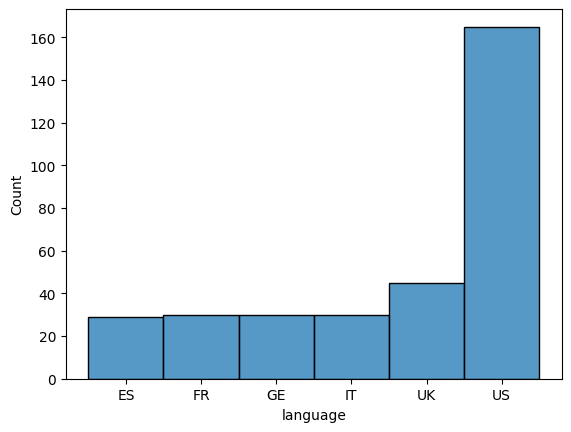

In [5]:
sns.histplot(df['language'])

### Drop the rows with NaN values, if any, show the shape of the dataset after this cleaning

In [40]:
dfclean=df.dropna()
print(f"rows: {dfclean.shape[0]}, cols: {dfclean.shape[1]}")

rows: 321, cols: 13


In [49]:
dfclean.isna().sum()

language    0
X1          0
X2          0
X3          0
X4          0
X5          0
X6          0
X7          0
X8          0
X9          0
X10         0
X11         0
X12         0
dtype: int64

###  tune the hyper–parameters of Model1 with Cross Validation on the training set, optimize for recall_macro

In [45]:
from sklearn.model_selection import train_test_split

X = dfclean.drop('language', axis = 1)
y = dfclean['language']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 2/3, random_state = random_state)
print(f"We have {Xtrain.shape[0]} items in our training set")
print(f"We have {Xtest.shape[0]} items in our test set")

We have 214 items in our training set
We have 107 items in our test set


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Instantiate the DecisionTree Classifier
Model1 = DecisionTreeClassifier(random_state = random_state)

# Fit it to the training data
Model1.fit(Xtrain, ytrain)

# Create the range of parameters to try during cross-validation
dt_depths = range(1, Model1.get_depth() + 1)

scores = []

for par in dt_depths :
    model1 = DecisionTreeClassifier(criterion = 'entropy', max_depth = par, random_state = random_state)
    score = cross_val_score(model1, Xtrain, ytrain, scoring = 'recall_macro', cv=5)
    scores.append(np.mean(score))
    #scores.append(sum(score) / len(score))
print (scores)



[np.float64(0.18174603174603174), np.float64(0.34354256854256854), np.float64(0.4003968253968254), np.float64(0.5199134199134199), np.float64(0.5583694083694083), np.float64(0.5357503607503608), np.float64(0.5440836940836941), np.float64(0.5317821067821068), np.float64(0.525036075036075), np.float64(0.525036075036075)]


### produce a classification report for Model1 on the test set

In [50]:
too_par = dt_depths[np.argmax(scores)]                          #prende l'indice il risultato migliore , best score
model1 = DecisionTreeClassifier(max_depth = too_par, criterion = 'entropy',random_state=random_state)
model1.fit(Xtest,ytest)
ytest_model = model1.predict(Xtest)
#Calculate the accuracy
accuracy = accuracy_score(ytest,ytest_model)*100
print("The accuracy on test set tuned with cross_validation with Model1 is {:.2f}% with depth {}".format(accuracy,too_par))

The accuracy on test set tuned with cross_validation with Model1 is 82.24% with depth 5


### produce the confusion matrix for Model1 on the test set

The accuracy score for the Decision Tree with the optimized hyperparameters was: 82.24%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

          ES       1.00      1.00      1.00        10
          FR       0.75      0.90      0.82        10
          GE       0.67      0.73      0.70        11
          IT       0.54      0.58      0.56        12
          UK       0.73      0.85      0.79        13
          US       0.96      0.84      0.90        51

    accuracy                           0.82       107
   macro avg       0.77      0.82      0.79       107
weighted avg       0.84      0.82      0.83       107



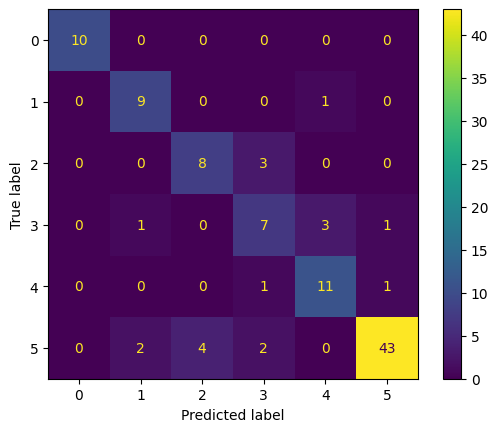

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Accuracy score
dt_accuracy = accuracy_score(ytest, ytest_model) * 100
print(f"The accuracy score for the Decision Tree with the optimized hyperparameters was: {dt_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_DT = confusion_matrix(ytest,ytest_model)
CMD = ConfusionMatrixDisplay(cm_DT)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, ytest_model))

### tune the hyper–parameters of Model2 with Cross Validation on the training set, optimize for recall_macro 

In [55]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the KNN Classifier
model2 = KNeighborsClassifier()

# Create the range of parameters to try during cross-validation
knn_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
scores2 = []
for i in knn_neighbors :
    model2 = KNeighborsClassifier(n_neighbors = i, metric = 'euclidean')
    score2 = cross_val_score(model2, Xtrain, ytrain, scoring = 'recall_macro', cv=5)
    scores2.append(np.mean(score2))
print (scores2)


[np.float64(0.7360750360750361), np.float64(0.7396825396825397), np.float64(0.7401154401154402), np.float64(0.6821789321789321), np.float64(0.6956709956709957), np.float64(0.7031385281385281), np.float64(0.6387806637806638), np.float64(0.6554473304473304), np.float64(0.641161616161616), np.float64(0.5955266955266956)]


### produce a classification report for Model2 on the test set

The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: 80.37%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

          ES       0.71      1.00      0.83        10
          FR       1.00      0.60      0.75        10
          GE       0.61      1.00      0.76        11
          IT       0.90      0.75      0.82        12
          UK       0.62      0.77      0.69        13
          US       0.93      0.78      0.85        51

    accuracy                           0.80       107
   macro avg       0.80      0.82      0.78       107
weighted avg       0.84      0.80      0.81       107



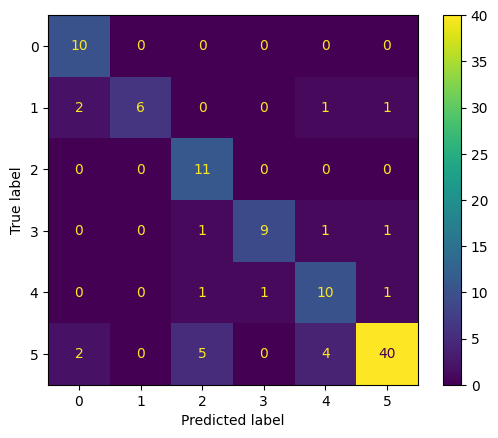

In [56]:
too_par = knn_neighbors[np.argmax(scores)]                          #prende l'indice il risultato migliore , best score
model2 = KNeighborsClassifier(n_neighbors = too_par, metric = 'euclidean')
model2.fit(Xtest,ytest)
ytest_model = model2.predict(Xtest)


# Accuracy score
knn_accuracy = accuracy_score(ytest, ytest_model) * 100
print(f"The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: {knn_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_KNN = confusion_matrix(ytest,ytest_model)
CMD = ConfusionMatrixDisplay(cm_KNN)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, ytest_model))